# 04 — Huấn luyện và đánh giá mô hình

So sánh ba thuật toán trên cùng một mẫu cố định tối đa 5.000 tin: Ridge Regression, Random Forest và XGBoost. Tập kiểm tra chiếm 20%; XGBoost thử CUDA rồi tự fallback CPU nếu GPU không dùng được.

**Chỉ số:** MAE và RMSE tính theo tỷ VND; R² càng gần 1 càng tốt. Kết quả thấp/âm là dấu hiệu cần cải thiện dữ liệu hoặc phân khúc, không nên diễn giải thành giá thẩm định.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / "src" / "pipeline.py").is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Không tìm thấy thư mục dự án có src/pipeline.py")
sys.path.insert(0, str(PROJECT_ROOT))

from IPython.display import display
from src.pipeline import MODEL_PATH, SCORES_PATH, train_and_save

scores, best_model = train_and_save()
display(scores.style.format({
    "MAE_ty": "{:.2f}",
    "RMSE_ty": "{:.2f}",
    "R2": "{:.3f}",
}, na_rep="—"))

valid = scores.dropna(subset=["RMSE_ty"])
best = valid.loc[valid["Model"] == best_model].iloc[0]
print(f"Mô hình tốt nhất theo RMSE: {best_model}")
print(f"Thiết bị: {best['Device']}")
print(f"MAE: {best['MAE_ty']:.2f} tỷ | RMSE: {best['RMSE_ty']:.2f} tỷ | R²: {best['R2']:.3f}")
print(f"Bảng điểm: {SCORES_PATH}")
print(f"Model: {MODEL_PATH}")

if best["R2"] < 0.5:
    print("Lưu ý: R² còn thấp; kết quả chỉ dùng minh họa học thuật.")


Huấn luyện trên 5,000/51,132 tin (seed=42).
Đang đánh giá: Linear Regression (Ridge)...
Đang đánh giá: Random Forest...
Đang đánh giá: XGBoost...
XGBoost đang chạy bằng GPU CUDA.
XGBoost đang chạy bằng GPU CUDA.
Model tốt nhất: XGBoost
Đã lưu model: D:\Dowload\Setup project\DuAnDuBaoGiaNhaTPHCM\models\gia_nha_tphcm.joblib


,Model,MAE_ty,RMSE_ty,R2,Device,Status
0,XGBoost,25.46,85.56,0.010,GPU,OK
1,Linear Regression (Ridge),26.26,86.48,-0.012,CPU,OK
2,Random Forest,27.23,87.50,-0.036,CPU,OK


Mô hình tốt nhất theo RMSE: XGBoost
Thiết bị: GPU
MAE: 25.46 tỷ | RMSE: 85.56 tỷ | R²: 0.010
Bảng điểm: D:\Dowload\Setup project\DuAnDuBaoGiaNhaTPHCM\outputs\model_comparison.csv
Model: D:\Dowload\Setup project\DuAnDuBaoGiaNhaTPHCM\models\gia_nha_tphcm.joblib
Lưu ý: R² còn thấp; kết quả chỉ dùng minh họa học thuật.


## Đọc kết quả

So sánh sai số tuyệt đối với phân phối giá ở Notebook 01. Một vài bất động sản rất đắt có thể chi phối RMSE và R²; nên báo cáo thêm sai số theo loại tài sản/khu vực khi cải tiến đồ án.

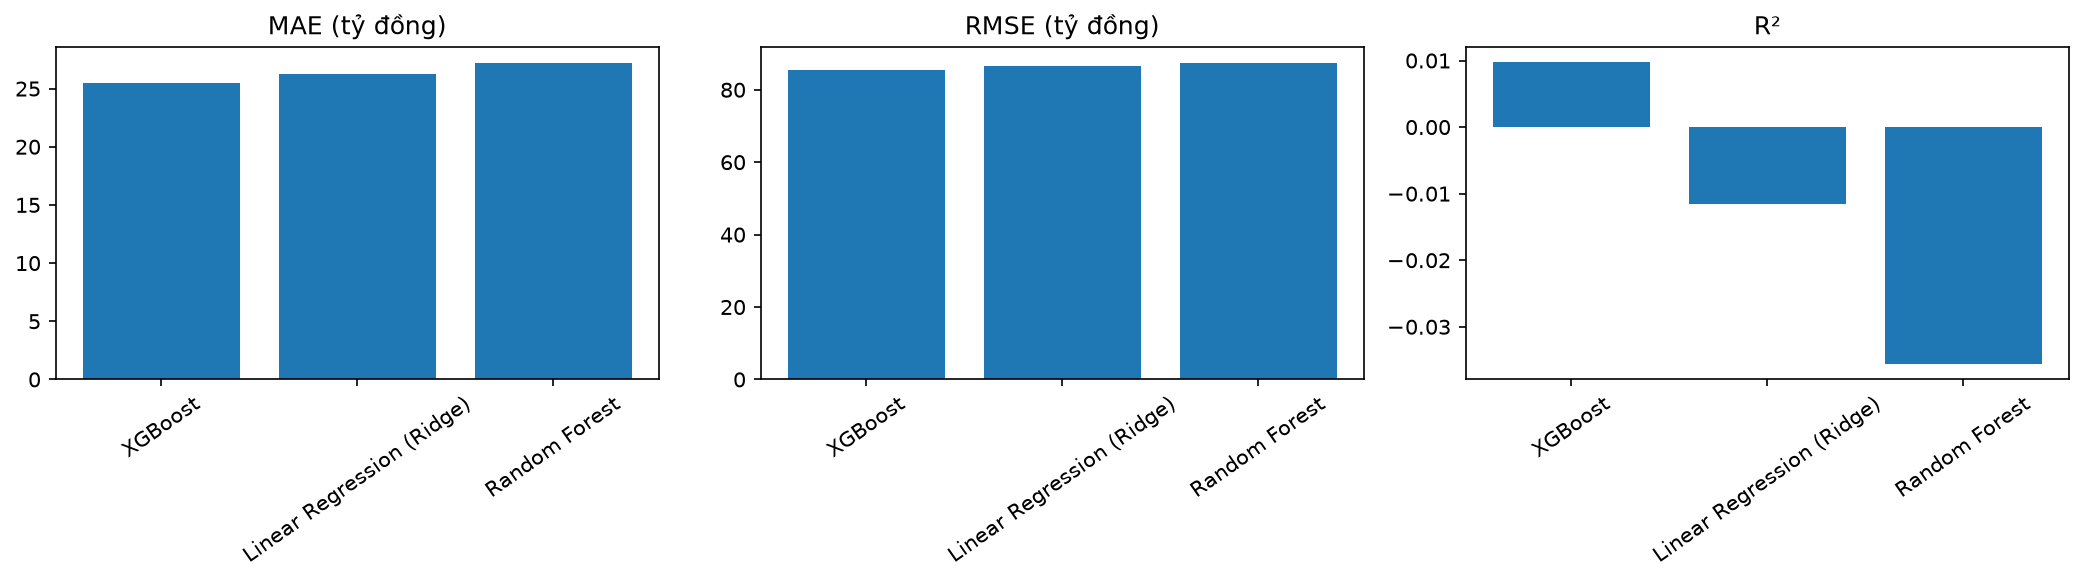

In [2]:
from IPython.display import Image, display

plot_path = PROJECT_ROOT / "outputs" / "model_comparison.png"
if plot_path.is_file():
    display(Image(filename=str(plot_path)))
